# Comparative Analysis of Machine Learning Models for Heart Disease Prediction Using MLflow

                                                            by Dora Gospodinova

# 1. Introduction

1.1. Project Overview

Cardiovascular diseases are among the leading causes of mortality worldwide. Timely detection of patients at increased risk is essential, as it allows for early treatment, reducing complications and improving quality of life.

Machine learning is an effective tool for analyzing medical data and its use supports the diagnostic process. By analyzing multiple clinical indicators, algorithms can detect dependencies that are difficult to detect with traditional statistical analysis.

This project investigates the application of several machine learning algorithms in predicting the presence of heart disease. In addition to building and comparing different models, the MLflow tool will also be used, which allows tracking experiments, storing models and comparing the results obtained.

1.2. Problem Definition

The main goal of the project is to develop and compare several machine learning models that can predict the presence of heart disease based on a patient's medical indicators.

Let each patient be described by multiple features

$$
X=(x_1,x_2,\ldots,x_n)
$$,

where each feature represents a medical characteristic such as age, gender, blood pressure, cholesterol level, maximum heart rate, and others.

The target variable is

$$
y \in \{0,1\}
$$,

where

0 – absence of heart disease;

1 – presence of heart disease.

Therefore, the task is a binary classification task, in which the model must determine to which of the two classes each patient belongs.


1.3. Project Objectives

The main objectives of the project are:

- analysis of the dataset and its characteristics;

- preparation and preprocessing of the data;

- feature size reduction using principal component analysis (PCA);

- training of several machine learning algorithms;

- comparison of the best of all models;

- evaluation using appropriate metrics;

- tracking of experiments using MLflow;

- selection of the most suitable model for predicting cardiac outcome.

# 2. Theoretical Background

This chapter introduces the fundamental machine learning concepts that are used throughout the project. It explains the classification problem, the importance of heart disease prediction, and the machine learning algorithms applied in the analysis.

2.1 Machine Learning

Machine Learning is a branch of Artificial Intelligence (AI) that enables computer systems to learn patterns from data and make predictions without being explicitly programmed.

Instead of following predefined rules, machine learning algorithms improve their performance by analyzing historical data and identifying relationships between variables.

Depending on the availability of labeled data, machine learning methods are commonly divided into:

- Supervised Learning;
- Unsupervised Learning;
- Reinforcement Learning.

This project focuses on Supervised Learning, where the target variable is known during the training process.

2.2 Classification

Classification is one of the most common supervised learning tasks. The objective is to assign each observation to one of several predefined classes.

In this project the target variable has two possible values:

- 0 – No heart disease;
- 1 – Heart disease.

Since only two classes are possible, the problem is considered a binary classification problem.

Several classification algorithms are used in this project, including Logistic Regression, Decision Tree and Random Forest.

2.3 Heart Disease Prediction

Cardiovascular diseases are among the leading causes of death worldwide. Early detection of heart disease can significantly improve treatment outcomes and reduce health risks.

Machine learning techniques can analyze patient information such as age, blood pressure, cholesterol level and other medical indicators to estimate the probability of heart disease.

The purpose of this project is to compare different machine learning models and determine which one provides the best predictive performance for the selected dataset.

2.4 Evaluation Metrics

The performance of the classification models is evaluated using several commonly used metrics.

- Accuracy measures the proportion of correctly classified observations.
- Precision measures how many predicted positive cases are actually positive.
- Recall measures how many actual positive cases are correctly identified.
- F1 Score is the harmonic mean of Precision and Recall.

These metrics provide a comprehensive evaluation of model performance and allow an objective comparison between different machine learning algorithms.

# 3. Dataset Description

3.1. UCI Heart Disease Dataset

The project uses the Heart Disease Dataset, which is derived from the UCI Machine Learning Repository and is widely used in training and research in the fields of machine learning and medical informatics. A CSV version of the dataset was used for ease of processing.

The dataset contains medical information about patients, collected for the purpose of analyzing the factors influencing the presence of heart disease. Each row represents a patient, and each column describes a certain medical indicator or characteristic.

The main task is, based on the available medical indicators, to predict whether a given patient suffers from heart disease.

3.2 Features Description

The following features are present in the dataset used:

| Feature  | Description                                                  |
| -------- | ------------------------------------------------------------ |
| age      | Patient age (in years)                                       |
| sex      | Gender (1 – male, 0 – female)                                |
| cp       | Chest pain type                                              |
| trestbps | Resting blood pressure (mm Hg)                               |
| chol     | Cholesterol level (mg/dl)                                    |
| fbs      | Fasting blood sugar (>120 mg/dl)                             |
| restecg  | Resting electrocardiogram result                             |
| thalach  | Maximum heart rate achieved                                  |
| exang    | Angina pectoris occurrence during exercise                   |
| oldpeak  | ST depression measured after exercise                        |
| slope    | ST segment slope                                             |
| ca       | Number of great vessels observed by fluoroscopy              |
| thal     | Thalassemia test result                                      |
| target   | Target variable (presence or absence of heart disease)       |

3.3 Target Variable

The target variable is target, which takes two possible values:

0 – the patient does not have heart disease;

1 – the patient has heart disease.

This defines the task as a binary classification, in which the algorithm must classify each patient into one of two classes.

# 4. Data Loading and Initial Exploration

In this section, the necessary libraries are imported, the dataset is loaded, and an initial review of its structure and content is performed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
sns.set_theme(style="whitegrid")

In [2]:
# Display settings

pd.set_option('display.max_columns', None)

# Load dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "data/processed.cleveland.data",
    header=None,
    names=columns,
    na_values="?"
)

# Display first five rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


The first five records from the dataset are shown to verify that the data was loaded correctly and that the columns are named correctly.

In [3]:
# Display dataset shape
print(df.shape)

(303, 14)


In [4]:
# Display dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
# Check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [6]:
# Remove missing values
df = df.dropna()

In [7]:
# Checking the new size
print(df.shape)

(297, 14)


In [8]:
# Convert 'ca' and 'thal' to numeric
df["ca"] = df["ca"].astype(float)
df["thal"] = df["thal"].astype(float)

In [9]:
# Convert target values to binary classes
df["target"] = (df["target"] > 0).astype(int)

In [10]:
# Checking the first records
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
#Statistical description
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


The main statistical characteristics of numerical features are presented - mean value, standard deviation, minimum and maximum value, as well as quartiles.

In [12]:
# Class distribution
df["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

The original Cleveland Heart Disease dataset contained 303 observations.

After removing records with missing values, 297 observations remained for further analysis.

The dataset contains 13 predictor variables and one target variable indicating the presence or absence of heart disease.
The dataset is now ready for exploratory data analysis and model development.

# 5. Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is a process of searching for data with a comprehensive understanding of its structure, distribution, and relationships between individual features.

The main objectives of the analysis are:

- examining the distribution of data;
- detecting missing values ​​and anomalies;
- analyzing dependencies between features;
- examining the relationship between features and the target variable;
- preparing data for building and training machine learning models.

5.1 Distribution of the Target Variable

Before building the models, it is important to analyze the distribution of the target variable. This shows whether the classes are balanced and whether there is no risk of the model being affected by imbalance in the data.

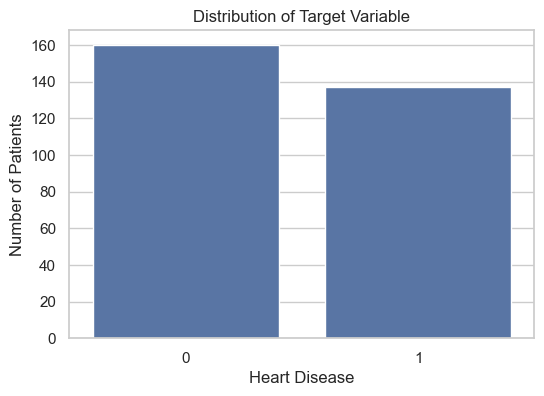

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

The graph shows that the two classes are relatively evenly distributed – 160 patients without heart disease and 137 patients with heart disease. This reduces the risk of the model being affected by imbalance between the classes.

In [14]:
df["target"].value_counts(normalize=True) * 100

target
0    53.872054
1    46.127946
Name: proportion, dtype: float64

The distribution of the target variable shows that the two classes are almost equally represented in the data set. The number of patients with heart disease is slightly higher than the number of patients without the disease, but the difference is insignificant.

A nearly balanced distribution is an important advantage in building machine learning models, as it reduces the risk that the model will be affected by imbalance between classes. This allows the use of standard classification algorithms without the need for data balancing techniques such as oversampling or undersampling.

5.2 Age Distribution

The next step is to analyze the age of the patients to determine how it is distributed in the data set.

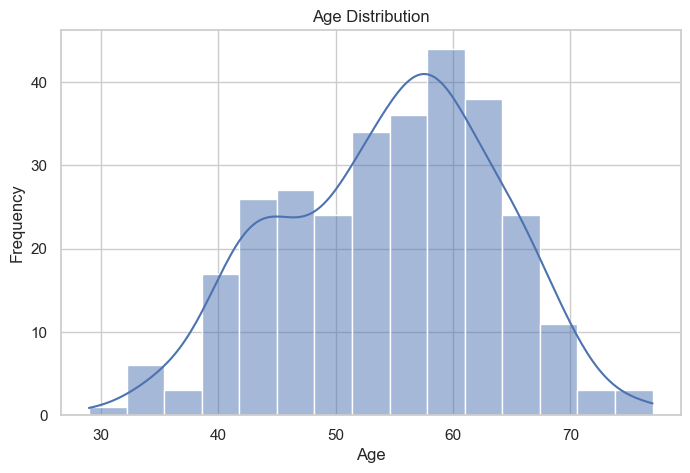

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Most patients are between the ages of 45 and 65. The highest concentration is observed around 55–60 years, indicating that this age group is most strongly represented in the dataset.

5.3 Age Distribution by Target

The following graph will show us whether patients with heart disease are typically older.

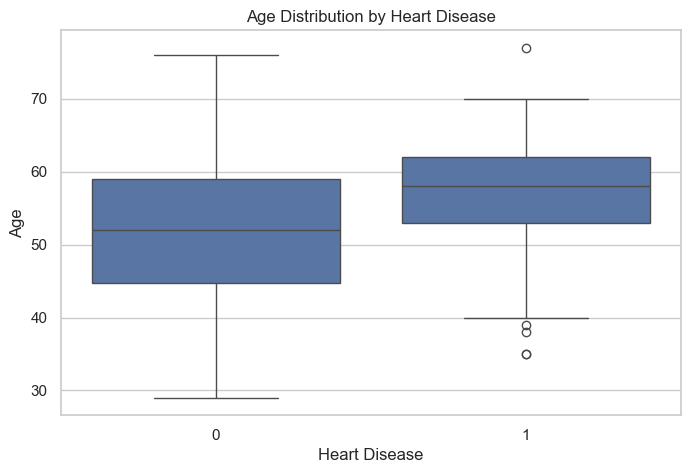

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

The age distribution is similar in both classes. Patients with heart disease are slightly older on average, but the difference is not significant.